<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Check_UnbalanceTechnique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

In [13]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall, AUC

In [14]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [22]:
# Copy data
data = df.copy()

In [23]:
data['AvgChargePerMonth'] = data['TotalCharges_numeric'] / (data['tenure'] + 1)

service_yes_cols = [
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',  # real service
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]
data['ServiceCount'] = data[service_yes_cols].sum(axis=1)

# Check first few rows to confirm
data[['AvgChargePerMonth', 'ServiceCount']].head()

,AvgChargePerMonth,ServiceCount
0,29.441096,1
1,1283.433962,3
2,105.227027,3
3,1132.769231,3
4,147.551351,2


In [ ]:
data.columns

In [24]:
scaler = MinMaxScaler()

# Columns to scale
cols_to_scale = ['AvgChargePerMonth', 'ServiceCount']

# Fit + transform
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [19]:
data.columns

Index(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalCharges_numeric', 'TotalCharges_log', 'gender_Male',
       'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'AvgChargePerMonth', 'ServiceCount'],
      dtype='object')

In [25]:
drop_cols = [
    'customerID',
    'MonthlyCharges',
    'TotalCharges',
    'TotalCharges_numeric',
    # ServiceCount component cols
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

X = data.drop(columns=drop_cols + ['Churn'])
y = data['Churn']

In [26]:
# Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale features to [0,1] using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shapes and class distribution
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 22) (5634,)
Test shape: (1409, 22) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


# **1. With Class Weights**

Class weights: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6711 - auc: 0.6484 - f1_score: 0.3069 - loss: 0.6460 - precision: 0.3354 - recall: 0.3116 - val_accuracy: 0.7107 - val_auc: 0.7545 - val_f1_score: 0.5271 - val_loss: 0.5453 - val_precision: 0.4630 - val_recall: 0.6576
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7283 - auc: 0.7909 - f1_score: 0.5648 - loss: 0.5624 - precision: 0.4780 - recall: 0.7206 - val_accuracy: 0.6957 - val_auc: 0.7880 - val_f1_score: 0.5629 - val_loss: 0.5400 - val_precision: 0.4526 - val_recall: 0.7763
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7243 - auc: 0.8171 - f1_score: 0.5922 - loss: 0.5233 - precision: 0.4871 - recall: 0.7880 - val_accuracy: 0.6894 - val_auc: 0.7965 - val_f1_score: 0.5656 - val_loss: 0.5522 - val_precision: 0.4478 - val_recall: 0.8000
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7206 - auc: 0.8271 - f1_score: 0.6044 - loss: 0.5168 - precision: 0.4972 - recall: 0.8037 - v

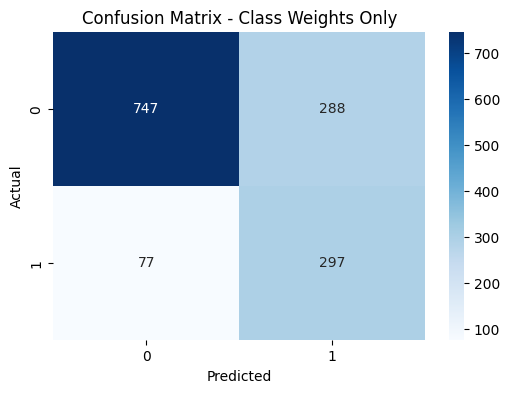

In [28]:
# Calculate class weights
# Classes
classes = np.unique(y_train)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to dictionary
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,  # applies class weights
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Class Weights Only')
plt.show()

# **SUMMARY**

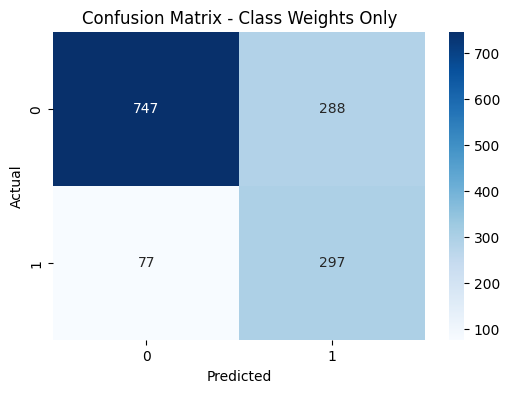